# Домашнее задание 2. Библиотеки для визуализаций в Python

Задание выполнил(а):

    (впишите свои фамилию и имя)

## Общая информация

__Внимание!__  

Домашнее задание выполняется самостоятельно. Не допускается помощь в решении домашнего задания от однокурсников или третьих лиц. «Похожие» решения считаются плагиатом, и все задействованные студенты — в том числе и те, у кого списали, — не могут получить за него больше 0 баллов. Использование в решении домашнего задания генеративных моделей (ChatGPT и так далее) за рамками справочной и образовательной информации для генерации кода задания — считается плагиатом, и такое домашнее задание оценивается в 0 баллов.

Каждое задание весит 0.5 или 1 балл (указано рядом с номером задания). Всего в сумме можно получить, если правильно решить все задания, 10 баллов.

## Раздел 1. Визуализации в датасете кредитного скоринга

### О задании

Вы будете работать с задачей кредитного скоринга (оценка надёжности клиента). Предоставляются данные о 1000 клиентов, про которых известно около 20 признаков и положительная или отрицательная оценка в качестве кредитуемого. Эти данные нужно исследовать с помощью средств визуализации.

*Описание данных*:
https://www.rdocumentation.org/packages/evtree/versions/1.0-8/topics/GermanCredit

Каждый построенный график необходимо красиво оформить – для этого требуется как минимум указать его название, а также отметить, что изображено по каждой из осей.
Также по каждому графику ожидается небольшой комментарий с выводами.

*Функции, которые могут пригодиться при оформлении графиков: `.show()`, `.title()`, `.xlabel()`, `.ylabel()`*

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
GERMAN_CREDIT = 'https://github.com/evgpat/datasets/raw/refs/heads/main/german_credit.csv'

### Задание 1 (0.5 балла)

Используя `numpy` и `matplotlib`, начнём с тренировки: постройте график функций $sin(x)$ и $cos(x)$ на интервале от $-\pi$ до $\pi$, используя 100 точек. Добавьте легенду и сетку.. Используйте для линий разные цвета, одна из них пусть будет пунктирной. Результат в этом и следующих заданиях на построение графиков должен получиться примерно как на картинке. Содержание подписей не должно обязательно совпадать, однако осмысленные подписи должны присутствовать на графиках.

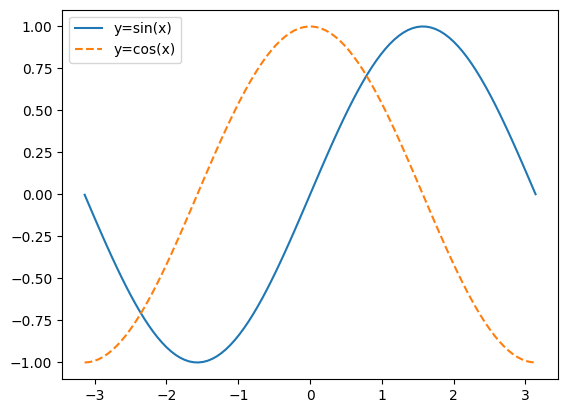

In [31]:
plt.style.use("default")

x = np.linspace(-3.14, 3.14, 100)

y1 = np.sin(x)
y2 = np.cos(x)

plt.plot(x, y1, label="y=sin(x)")
plt.plot(x, y2, linestyle="--", label="y=cos(x)")

plt.legend()
plt.show()



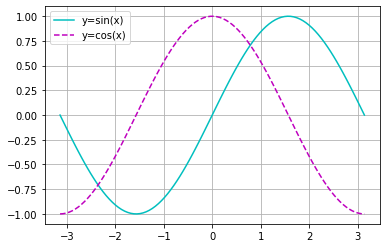

In [ ]:
# то что должно получиться

### Задание 2 (0.5 балла)

Прочитайте средствами pandas файл с данными кредитного скоринга. Рассмотрите сравнительное количество положительных и отрицательных кейсов в зависимости от размера текущего счёта. Постройте зеркальные горизонтальные гистограммы.

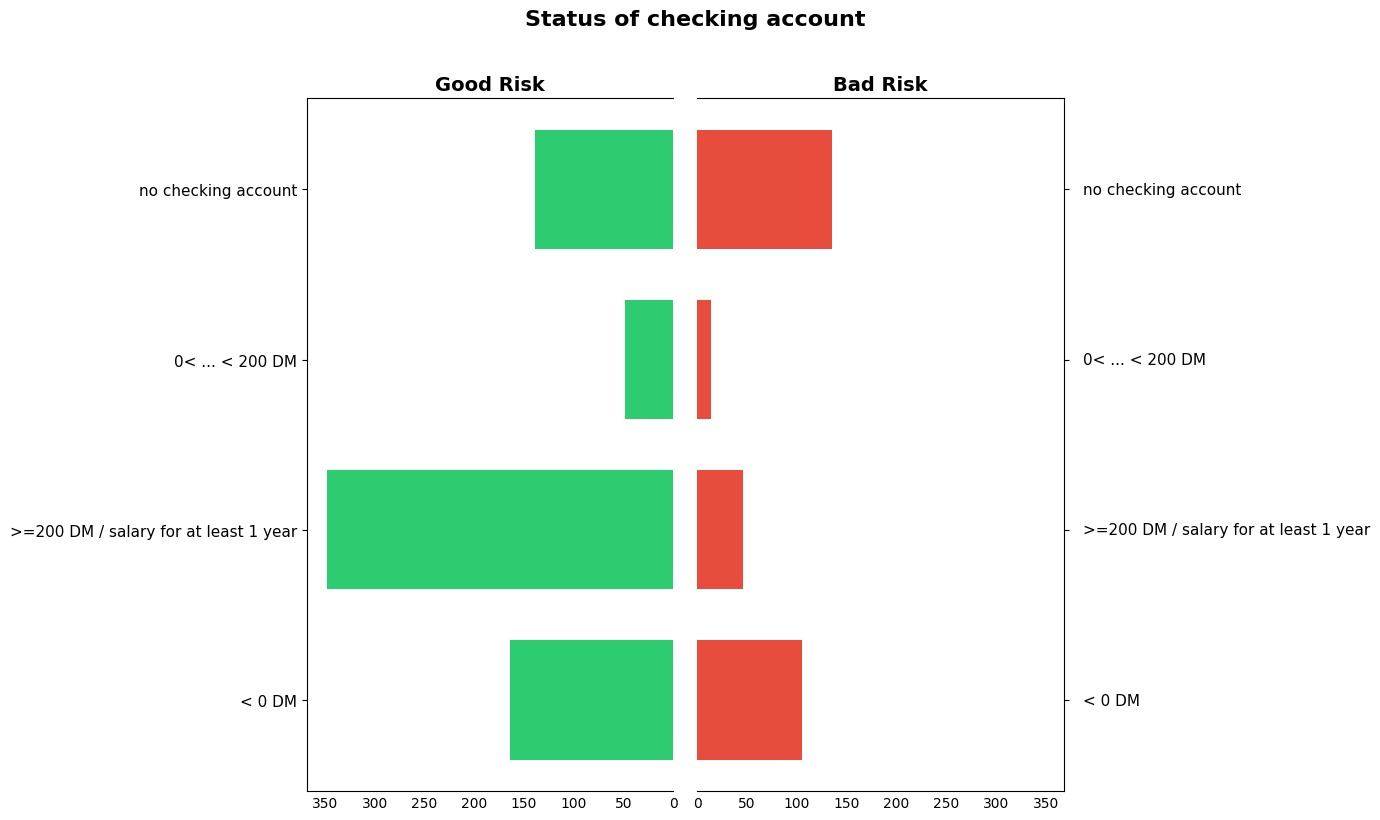

In [30]:
plt.style.use('default')

url = 'https://github.com/evgpat/datasets/raw/refs/heads/main/german_credit.csv'
df = pd.read_csv(url)

df['status_display'] = df['status'].replace({
    'no checking account': 'no checking account',
    '0<= ... < 200 DM': '0< ... < 200 DM',
    '... >= 200 DM / salary for at least 1 year': '>=200 DM / salary for at least 1 year',
    '... < 0 DM': '< 0 DM'
})

categories_order = [
    'no checking account',
    '0< ... < 200 DM',
    '>=200 DM / salary for at least 1 year',
    '< 0 DM'
]

good_counts = []
bad_counts = []

for category in categories_order:
    good_counts.append(
        df[(df['status_display'] == category) & (df['credit_risk'] == 'good')].shape[0]
    )
    bad_counts.append(
        df[(df['status_display'] == category) & (df['credit_risk'] == 'bad')].shape[0]
    )

good_counts = np.array(good_counts)
bad_counts = np.array(bad_counts)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 8))
fig.subplots_adjust(wspace=0.02)

good_color = '#2ecc71'
bad_color = '#e74c3c'

y_pos = np.arange(len(categories_order))

ax1.barh(
    y_pos,
    -good_counts,
    color=good_color,
    height=0.7
)

ax1.set_title('Good Risk', fontsize=14, fontweight='bold')
ax1.set_xlabel('')
ax1.set_yticks(y_pos)
ax1.set_yticklabels(categories_order, fontsize=11, ha='right')

ax1.invert_xaxis()
ax1.invert_yaxis()

ax1.grid(False)
ax1.spines['right'].set_visible(False)
ax1.tick_params(axis='x', length=0)

ax2.barh(
    y_pos,
    bad_counts,
    color=bad_color,
    height=0.7
)

ax2.set_title('Bad Risk', fontsize=14, fontweight='bold')
ax2.set_xlabel('')
ax2.set_yticks(y_pos)
ax2.set_yticklabels([])
ax2.yaxis.tick_right()
ax2.yaxis.set_label_position("right")

ax2.spines['right'].set_visible(True)
ax2.spines['left'].set_visible(False)

ax2.invert_yaxis()

ax2.grid(False)
ax2.spines['left'].set_visible(False)
ax2.tick_params(axis='x', length=0)

ax2.set_ylim(ax1.get_ylim())

max_count = max(max(good_counts), max(bad_counts))
ax1.set_xlim(-max_count - 20, 0)
ax2.set_xlim(0, max_count + 20)

good_ticks = np.arange(0, max_count + 50, 50)
ax1.set_xticks(-good_ticks)
ax1.set_xticklabels(good_ticks.astype(int))

right_label_x = max_count + 40
for i, label in enumerate(categories_order):
    ax2.text(
        right_label_x,
        i,
        label,
        ha='left',
        va='center',
        fontsize=11
    )

plt.suptitle(
    'Status of checking account',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

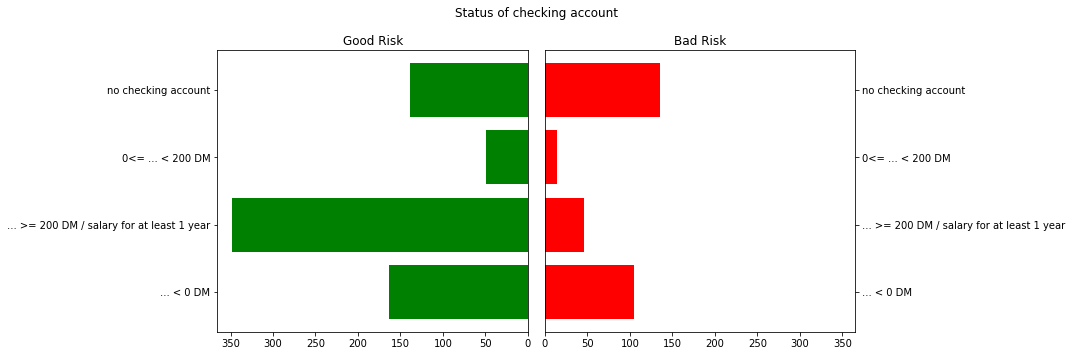

In [ ]:
# то что должно получиться

### Задание 3  (0.5 балла)

In [113]:
import seaborn as sns

Теперь постройте гистограмму для сравнения количества положительных и отрицательных кейсов в зависимости от размера сберегательного счёта с помощью seaborn. Какой способ вам больше нравится с точки зрения трудоёмкости написания кода? А с точки зрения восприятия результата?

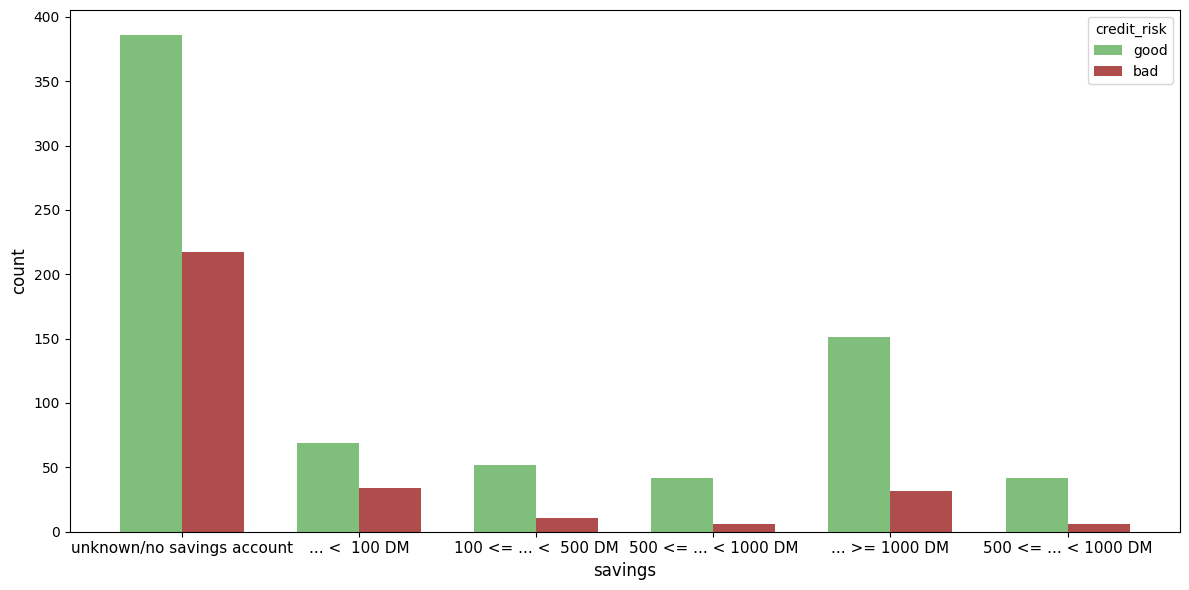

In [26]:
plt.style.use('default')

url = 'https://github.com/evgpat/datasets/raw/refs/heads/main/german_credit.csv'
df = pd.read_csv(url)

df['savings_display'] = df['savings']  


categories = [
    'unknown/no savings account',
    '... <  100 DM',          
    '100 <= ... <  500 DM',    
    '500 <= ... < 1000 DM',
    '... >= 1000 DM',
    '500 <= ... < 1000 DM'
]

good_counts = []
bad_counts = []

for cat in categories:
    good_counts.append(df[(df['savings_display'] == cat) & (df['credit_risk'] == 'good')].shape[0])
    bad_counts.append(df[(df['savings_display'] == cat) & (df['credit_risk'] == 'bad')].shape[0])

x = np.arange(len(categories))
width = 0.35

plt.figure(figsize=(12, 6))

plt.bar(x - width/2, good_counts, width, label='good', color='#7fbf7b')
plt.bar(x + width/2, bad_counts, width, label='bad', color='#af4c4c')

plt.xlabel('savings', fontsize=12)
plt.ylabel('count', fontsize=12)
plt.xticks(x, categories, rotation=0, fontsize=11)
plt.legend(title='credit_risk')

plt.tight_layout()
plt.show()

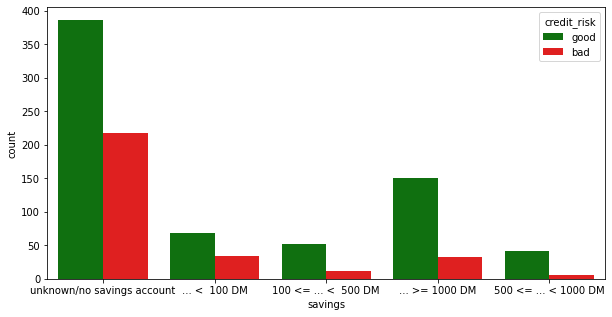

In [ ]:
# то что должно получиться

### Задание 4  (0.5 балла)

seaborn легко позволяет добавить ещё больше информации на один график. Для каждого размера сберегательного счёта мы можем оценить не только количество положительных и отрицательных кейсов, но и их распределение по возрасту, например. Постройте подходящую для этого визуализацию.

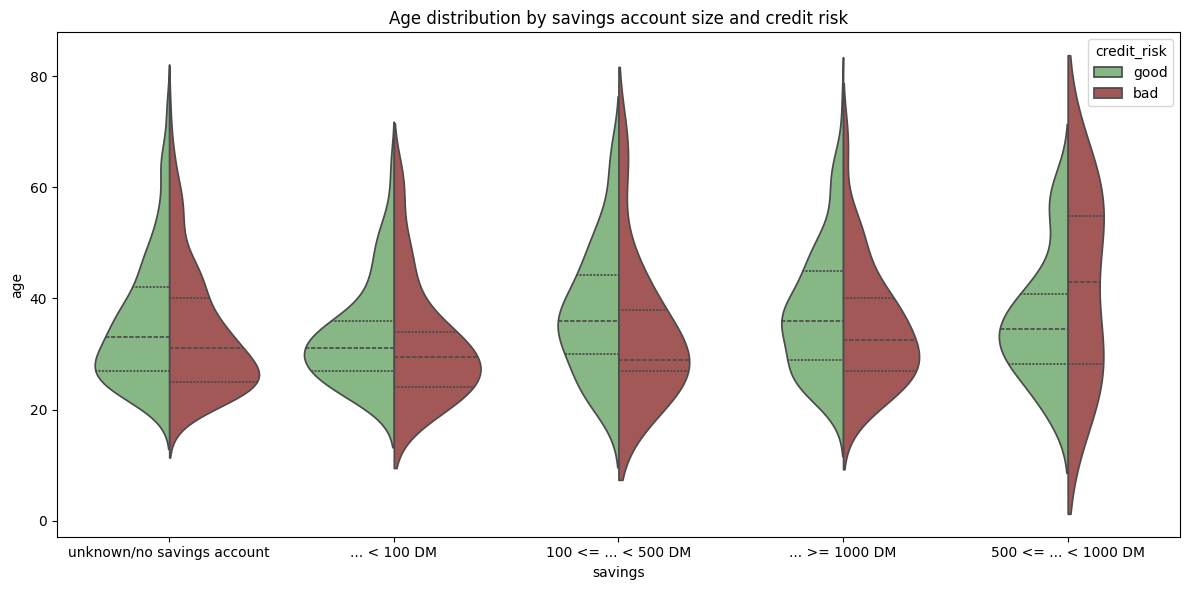

In [18]:
url = 'https://github.com/evgpat/datasets/raw/refs/heads/main/german_credit.csv'
df = pd.read_csv(url)

df['savings_display'] = df['savings'].replace({
    'unknown/no savings account': 'unknown/no savings account',
    '... <  100 DM': '... < 100 DM',          
    '100 <= ... <  500 DM': '100 <= ... < 500 DM',  
    '500 <= ... < 1000 DM': '500 <= ... < 1000 DM',
    '... >= 1000 DM': '... >= 1000 DM'
})

categories_order = [
    'unknown/no savings account',
    '... < 100 DM',           
    '100 <= ... < 500 DM',    
    '... >= 1000 DM',          
    '500 <= ... < 1000 DM'     
]

plt.figure(figsize=(12, 6))

sns.violinplot(
    data=df,
    x='savings_display',
    y='age',
    hue='credit_risk',
    order=categories_order,
    split=True,
    palette={'good': '#7fbf7b', 'bad': '#af4c4c'},
    inner='quartile'
)

plt.xlabel('savings')
plt.ylabel('age')
plt.title('Age distribution by savings account size and credit risk')
plt.legend(title='credit_risk')
plt.tight_layout()
plt.show()

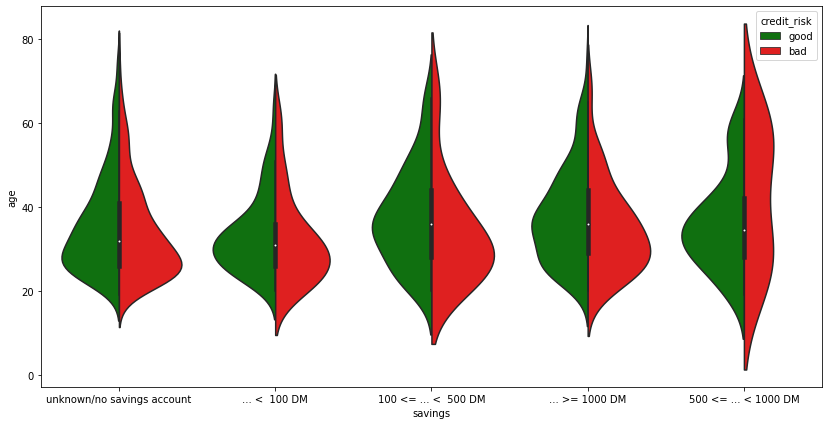

In [ ]:
# то что должно получиться

### Задание 5  (0.5 балла)

Заканчивая с гистограммами, посмотрим на распределение положительных и отрицательных кейсов по возрастам, разместив их друг над другом. Добавим распределение всех взятых кредитов.

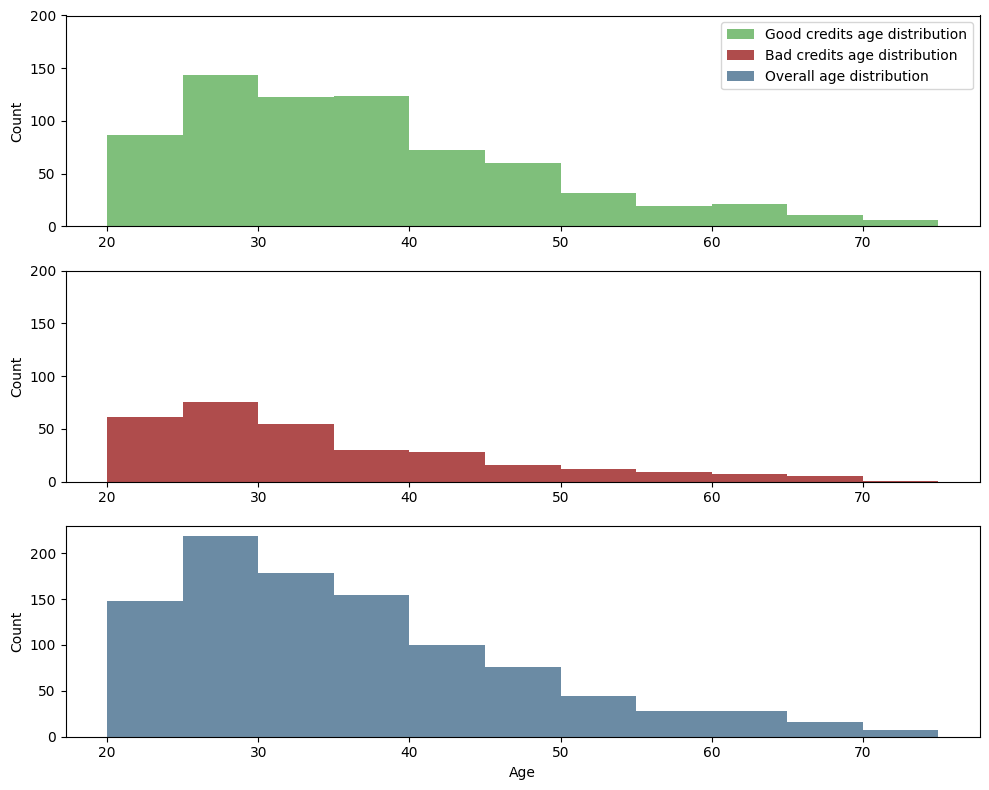

In [17]:
url = 'https://github.com/evgpat/datasets/raw/refs/heads/main/german_credit.csv'
df = pd.read_csv(url)

plt.style.use('default')

ages_good = df[df['credit_risk'] == 'good']['age']
ages_bad = df[df['credit_risk'] == 'bad']['age']
ages_all = df['age']

bins = np.arange(20, 76, 5) 

good_color = '#7fbf7b'
bad_color = '#af4c4c'
all_color = '#6b8ba4'

fig, axes = plt.subplots(3, 1, figsize=(10, 8), sharex=True)

axes[0].hist(
    ages_good,
    bins=bins,
    color=good_color,
    label='Good credits age distribution'
)
axes[0].set_ylabel('Count')

axes[1].hist(
    ages_bad,
    bins=bins,
    color=bad_color,
    label='Bad credits age distribution'
)
axes[1].set_ylabel('Count')

axes[2].hist(
    ages_all,
    bins=bins,
    color=all_color,
    label='Overall age distribution'
)
axes[2].set_ylabel('Count')
axes[2].set_xlabel('Age')

for ax in axes:
    ax.set_yticks([0, 50, 100, 150, 200])
    ax.set_xticks([20, 30, 40, 50, 60, 70])

handles = []
labels = []

for ax in axes:
    h, l = ax.get_legend_handles_labels()
    handles.extend(h)
    labels.extend(l)
    ax.tick_params(labelbottom=True)  

axes[0].legend(handles, labels, loc='upper right')

plt.tight_layout()
plt.show()


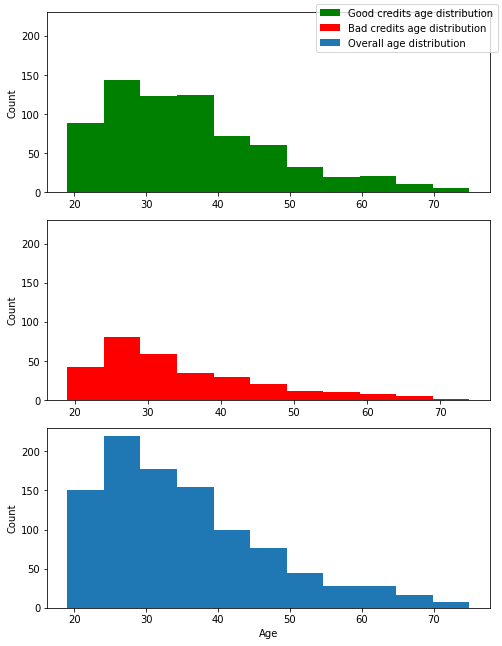

In [ ]:
# то что должно получиться

### Задание 6  (0.5 балла)

Не менее полезной иногда может быть диаграмма рассеяния. Постройте такую диаграмму с продолжительностью и размерами кредитов в качестве осей. Обозначьте положительные и отрицательные кейсы разными цветами.

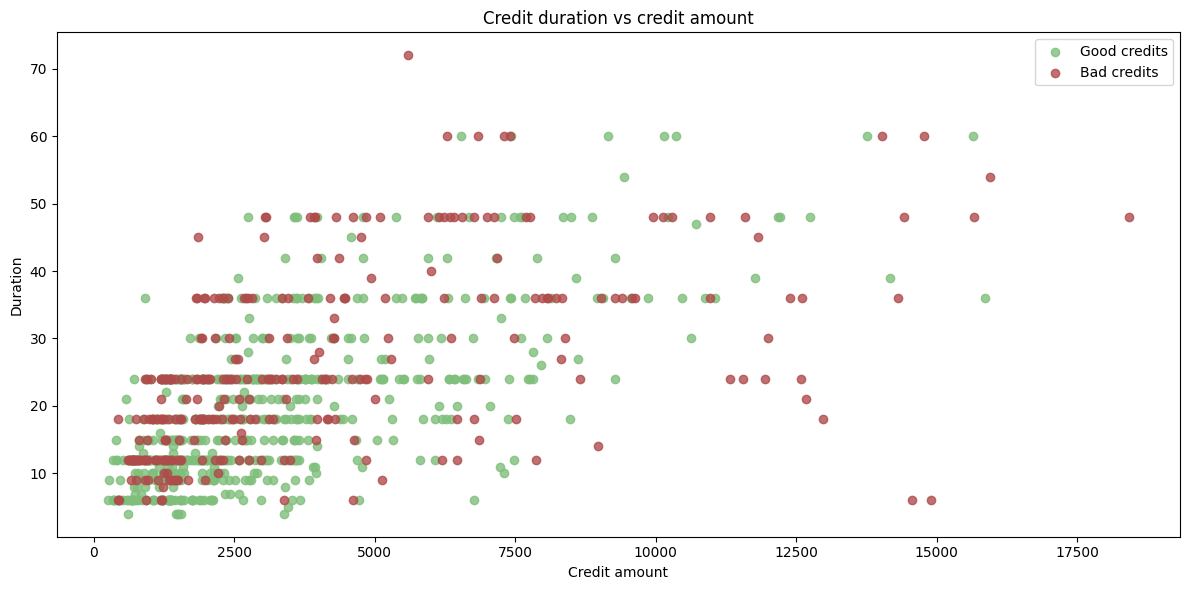

In [16]:
url = 'https://github.com/evgpat/datasets/raw/refs/heads/main/german_credit.csv'
df = pd.read_csv(url)

plt.style.use('default')

good = df[df['credit_risk'] == 'good']
bad = df[df['credit_risk'] == 'bad']

good_color = '#7fbf7b'
bad_color = '#af4c4c'

plt.figure(figsize=(12, 6))

plt.scatter(
    good['amount'],     
    good['duration'],
    color=good_color,
    alpha=0.8,
    label='Good credits'
)

plt.scatter(
    bad['amount'],      
    bad['duration'],
    color=bad_color,
    alpha=0.8,
    label='Bad credits'
)

plt.xlabel('Credit amount')
plt.ylabel('Duration')
plt.title('Credit duration vs credit amount')
plt.legend()

plt.tight_layout()
plt.show()


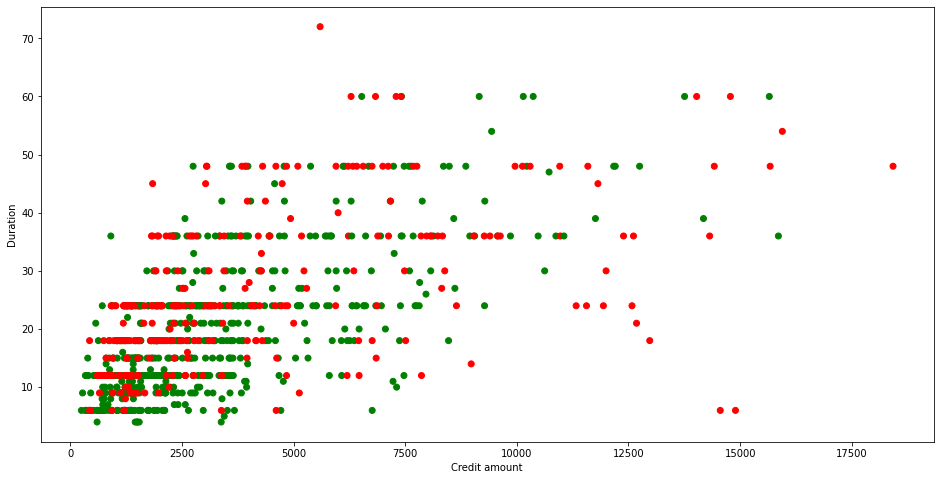

In [ ]:
# то что должно получиться

### Задание 7  (0.5 балла)

Продвинемся глубже. Постройте 3D версию диаграммы рассеяния, добавив ось с возрастом.

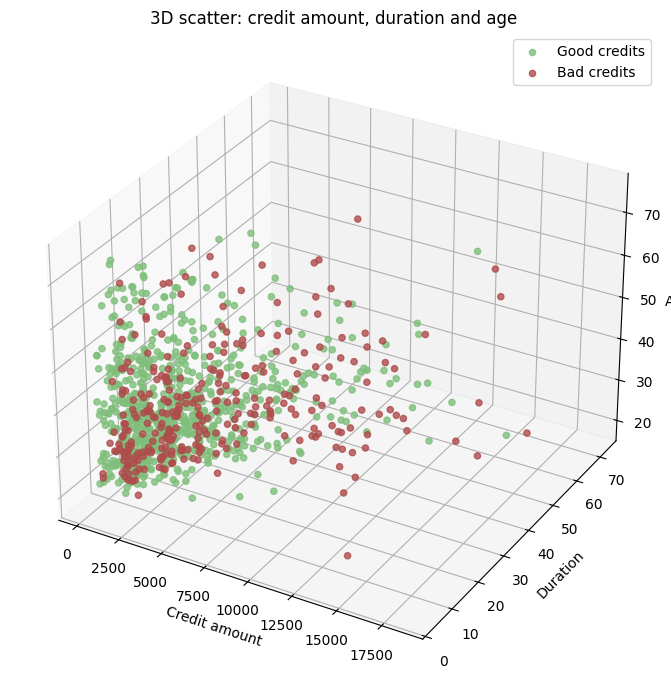

In [15]:
url = 'https://github.com/evgpat/datasets/raw/refs/heads/main/german_credit.csv'
df = pd.read_csv(url)

plt.style.use('default')

good = df[df['credit_risk'] == 'good']
bad = df[df['credit_risk'] == 'bad']

good_color = '#7fbf7b'
bad_color = '#af4c4c'

fig = plt.figure(figsize=(12, 7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    good['amount'],
    good['duration'],
    good['age'],
    color=good_color,
    alpha=0.8,
    label='Good credits'
)

ax.scatter(
    bad['amount'],
    bad['duration'],
    bad['age'],
    color=bad_color,
    alpha=0.8,
    label='Bad credits'
)

ax.set_xlabel('Credit amount')
ax.set_ylabel('Duration')
ax.set_zlabel('Age')

ax.set_title('3D scatter: credit amount, duration and age')

ax.legend()

plt.tight_layout()
plt.show()



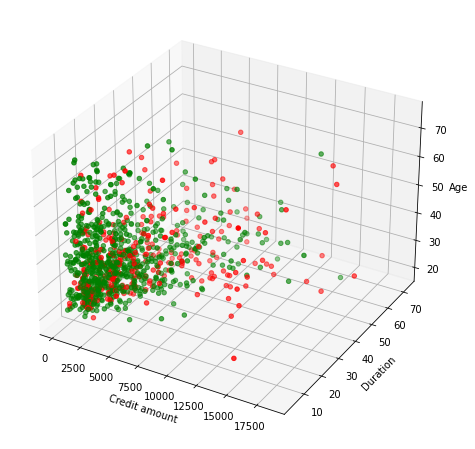

In [ ]:
# то что должно получиться

Что вы можете сказать о сравнении 3D- и 2D-визуализаций? Какие вы видите в них преимущества и недостатки?

Какие выводы с точки зрения бизнеса можно сделать из полученного графика?

**ВАШ ОТВЕТ**  
...

## Раздел 2. Визуализации в датасете Netflix

В данном разделе вы продолжите практиковаться в визуализациях и поработаете с более сложными графиками и инструментами.

Все технические рекомендации остаются неизменными с прошлого раздела.

In [5]:
NETFLIX_TITLES = 'https://github.com/evgpat/datasets/raw/refs/heads/main/netflix_titles.csv'

### Задание 1  (0.5 балла)

Прочитайте средствами pandas файл с данными Netflix. Посчитайте количество пропусков (NaN) в колонке `director`. Постройте столбчатую диаграмму, которая показывает 5 стран, в которых наибольшее количество фильмов содержат пропуски в столбце `director`.

Добавьте на диаграмму:

- Заголовок жирным шрифтом
- Подписи осей

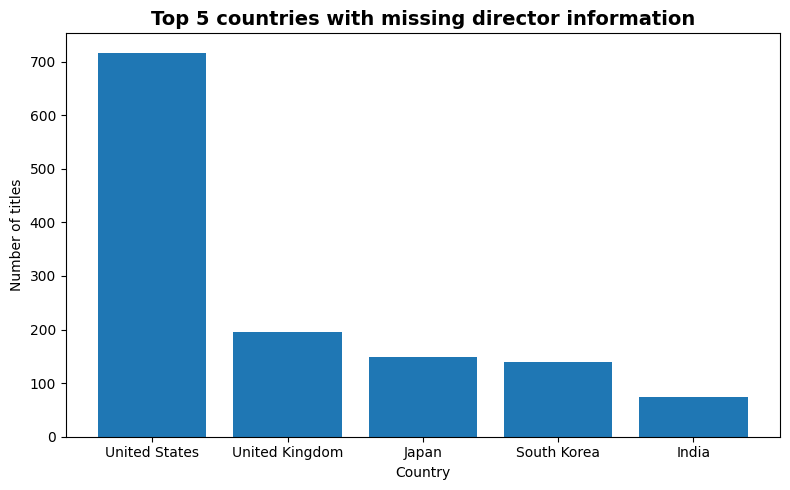

In [13]:
NETFLIX_TITLES = 'https://github.com/evgpat/datasets/raw/refs/heads/main/netflix_titles.csv'
netflix = pd.read_csv(NETFLIX_TITLES)

missing_director = netflix[netflix['director'].isna()]

top_countries = (
    missing_director['country']
    .dropna()
    .value_counts()
    .head(5)
)

plt.figure(figsize=(8, 5))

plt.bar(
    top_countries.index,
    top_countries.values
)

plt.title(
    'Top 5 countries with missing director information',
    fontsize=14,
    fontweight='bold'
)
plt.xlabel('Country')
plt.ylabel('Number of titles')

plt.tight_layout()
plt.show()


### Задание 2 (0.5 балла)

Постройте pie chart (круговую диаграмму), показывающую 5 стран, в которых произвели больше всего фильмов.

Добавьте на диаграмму:

+ Заголовок (Тип шрифта: ``family = 'monospace'``, насыщенность: ``fontweight='bold'``)
+ Название стран (Тип шрифта: ``family = 'monospace'``)
+ Подписи значений (%) (Тип шрифта: ``family = 'monospace'``)
+ Выберите стиль для диаграммы pastel c помощью библиотеки ``seaborn``

```colors = sns.color_palette('pastel')[0:5]```

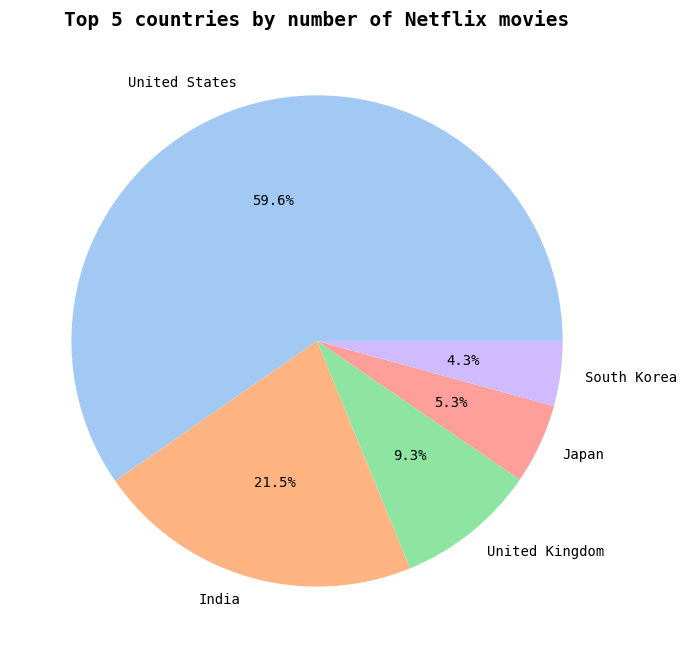

In [12]:
NETFLIX_TITLES = 'https://github.com/evgpat/datasets/raw/refs/heads/main/netflix_titles.csv'
netflix = pd.read_csv(NETFLIX_TITLES)

top_countries = (
    netflix['country']
    .dropna()
    .value_counts()
    .head(5)
)

colors = sns.color_palette('pastel')[0:5]

plt.figure(figsize=(7, 7))

plt.pie(
    top_countries.values,
    labels=top_countries.index,
    autopct='%1.1f%%',
    colors=colors,
    textprops={'family': 'monospace'}
)

plt.title(
    'Top 5 countries by number of Netflix movies',
    fontweight='bold',
    family='monospace',
    fontsize=14
)

plt.tight_layout()
plt.show()


### Задание 3 (1 балл)

Постройте subplots, где на первом графике будет круговая диаграмма, показывающая долю фильмов каждого рейтинга *(rating)*, а на втором столбчатая диаграмма, показывающая 3 страны, в которых было снято больше всего фильмов с рейтингом TV-MA.

*Если фильмов в каких-то рейтингах меньше 50, то их в график брать не нужно.*

Добавьте на диаграммы:

+ Заголовки (можно жирным)

Круговая диаграмма:
+ Подписи значений абсолютные

Столбчатая диаграммма:
+ Сделайте так, чтобы ось Y была справа
+ Добавьте подпись «Количество фильмов» к оси Y и уберите подпись к оси X
+ Оставьте видимыми только правую и нижнюю границы

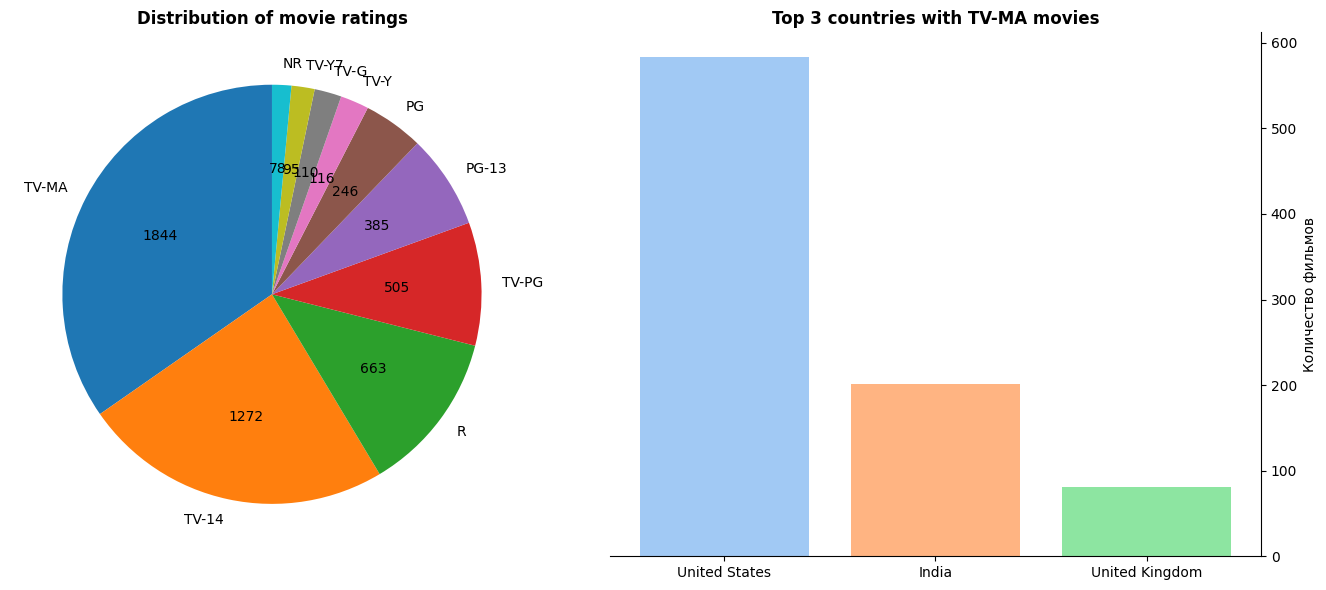

In [11]:
NETFLIX_TITLES = 'https://github.com/evgpat/datasets/raw/refs/heads/main/netflix_titles.csv'
netflix = pd.read_csv(NETFLIX_TITLES)

movies = netflix[netflix['type'] == 'Movie']

rating_counts = (
    movies['rating']
    .dropna()
    .value_counts()
)

rating_counts = rating_counts[rating_counts >= 50]

tv_ma_movies = movies[movies['rating'] == 'TV-MA']

top_tv_ma_countries = (
    tv_ma_movies['country']
    .dropna()
    .value_counts()
    .head(3)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(
    rating_counts.values,
    labels=rating_counts.index,
    autopct=lambda p: f'{int(p * rating_counts.sum() / 100)}',
    startangle=90
)

axes[0].set_title(
    'Distribution of movie ratings',
    fontweight='bold'
)

axes[1].bar(
    top_tv_ma_countries.index,
    top_tv_ma_countries.values,
    color=sns.color_palette('pastel')[0:3]
)

axes[1].set_title(
    'Top 3 countries with TV-MA movies',
    fontweight='bold'
)

axes[1].yaxis.tick_right()
axes[1].yaxis.set_label_position("right")
axes[1].set_ylabel('Количество фильмов')

axes[1].set_xlabel('')

axes[1].spines['top'].set_visible(False)
axes[1].spines['left'].set_visible(False)
axes[1].spines['right'].set_visible(True)
axes[1].spines['bottom'].set_visible(True)

plt.tight_layout()
plt.show()


### Задание 4 (1 балл)

Преобразуйте колонку `date_added` в datetime. Создайте новые столбцы month и year из преобразованного столбца. Постройте линейный график: сколько в среднем фильмов было снято в каждый из месяцев.

Добавьте на график:

+ Заголовок жирным шрифтом
+ Подписи осей
+ Маркеры на точках перегиба
+ Настройте ось X: ось начинается с 1 заканчивается 12, шаг 1

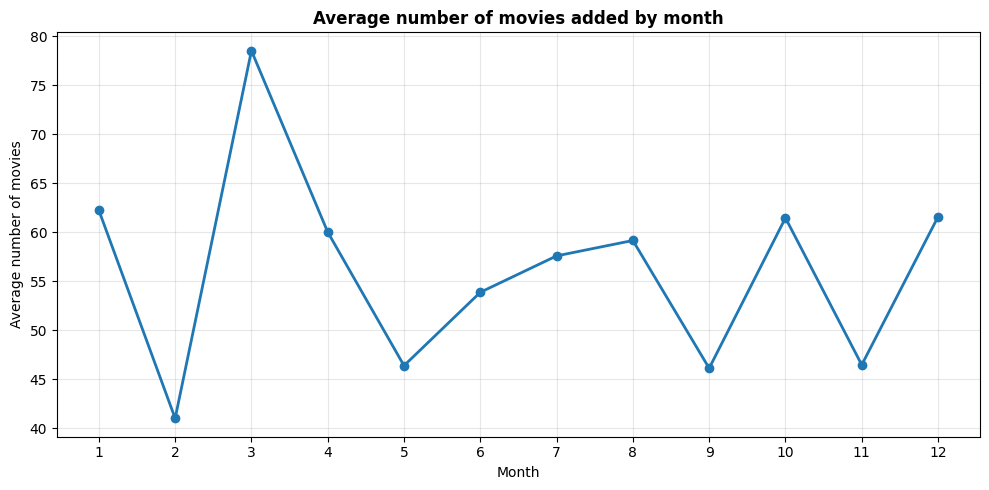

In [10]:
NETFLIX_TITLES = 'https://github.com/evgpat/datasets/raw/refs/heads/main/netflix_titles.csv'
netflix = pd.read_csv(NETFLIX_TITLES)

movies = netflix[netflix['type'] == 'Movie'].copy()

movies['date_added'] = pd.to_datetime(movies['date_added'], errors='coerce')

movies['month'] = movies['date_added'].dt.month
movies['year'] = movies['date_added'].dt.year

monthly_avg = (
    movies
    .groupby(['year', 'month'])
    .size()
    .groupby('month')
    .mean()
)

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_avg.index,
    monthly_avg.values,
    marker='o',          
    linewidth=2
)

plt.title(
    'Average number of movies added by month',
    fontweight='bold'
)

plt.xlabel('Month')
plt.ylabel('Average number of movies')

plt.xticks(np.arange(1, 13, 1))

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Задание 5 (1 балл)

Постройте линейный график, в какие годы (столбец year, который вы создали в задании 4) сколько фильмов было снято.

Добавьте на график:

+ Заголовок жирным шрифтом
+ Подписи осей
+ Измените цвет линии графика и сделайте ее пунктиром
+ Решетку на фон

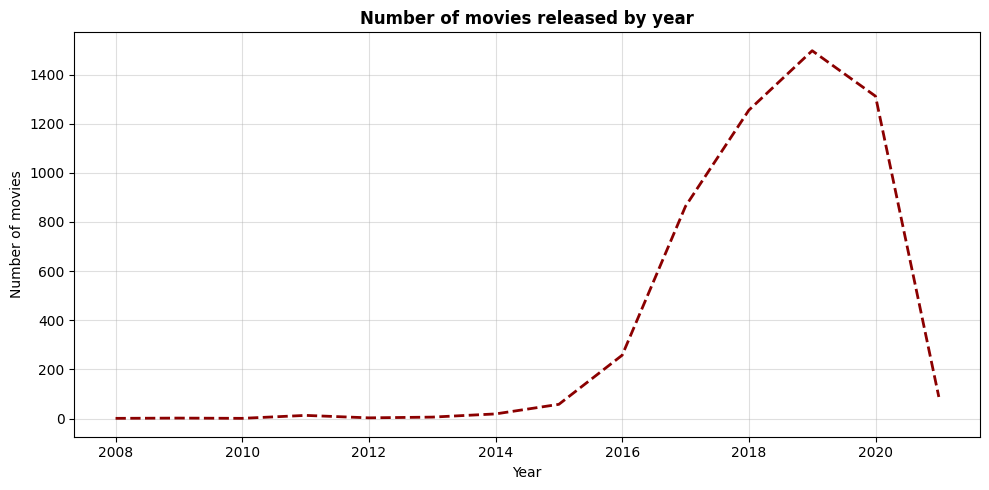

In [9]:
NETFLIX_TITLES = 'https://github.com/evgpat/datasets/raw/refs/heads/main/netflix_titles.csv'
netflix = pd.read_csv(NETFLIX_TITLES)

movies = netflix[netflix['type'] == 'Movie'].copy()

movies['date_added'] = pd.to_datetime(movies['date_added'], errors='coerce')
movies['year'] = movies['date_added'].dt.year

movies_per_year = movies['year'].value_counts().sort_index()

plt.figure(figsize=(10, 5))

plt.plot(
    movies_per_year.index,
    movies_per_year.values,
    color='darkred',      
    linestyle='--',       
    linewidth=2
)

plt.title(
    'Number of movies released by year',
    fontweight='bold'
)

plt.xlabel('Year')
plt.ylabel('Number of movies')

plt.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()


### Задание 6 (1 балл)

Будем работать со столбцом duration. Одни данные даны в минутах (для фильмов (Movie)), а другие в сезонах (для сериалов (TV shows)). Создайте два новых столбца min (для тех, у кого продолжительность в минутах) и season (для тех, у кого продолжительность в сезонах), в которых будут извлечены данные из столбца duration.

Постройте subplots, где на первом графике гистрограмма распределения продолжительности фильмов, а на втором – гистрограмма распределения продолжительности сериалов.

Добавьте на графики:

+ Заголовки жирным шрифтом
+ Подписи осей

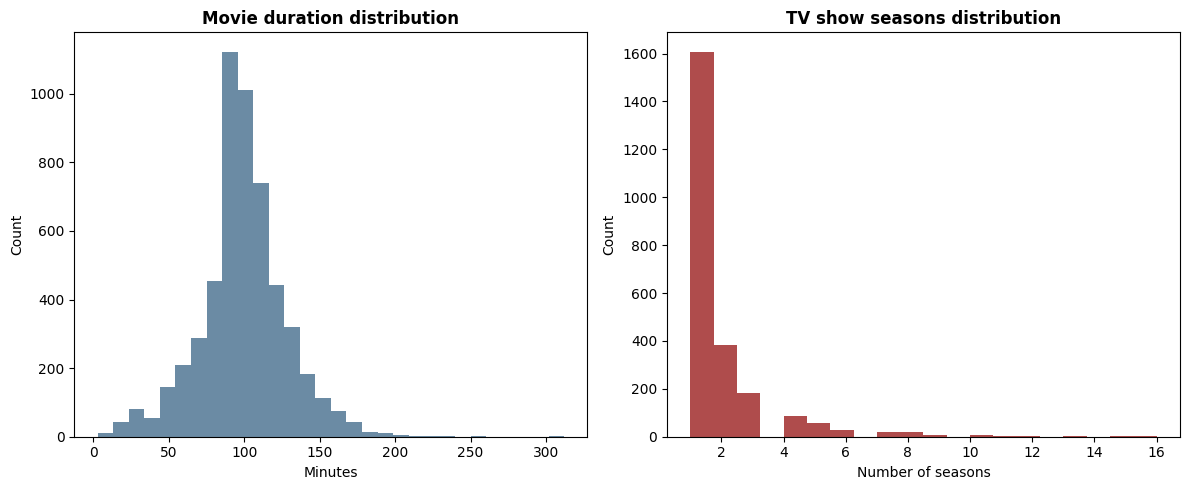

In [8]:
NETFLIX_TITLES = 'https://github.com/evgpat/datasets/raw/refs/heads/main/netflix_titles.csv'
netflix = pd.read_csv(NETFLIX_TITLES)

netflix['min'] = netflix.apply(
    lambda x: int(x['duration'].split()[0])
    if x['type'] == 'Movie' and isinstance(x['duration'], str)
    else None,
    axis=1
)

netflix['season'] = netflix.apply(
    lambda x: int(x['duration'].split()[0])
    if x['type'] == 'TV Show' and isinstance(x['duration'], str)
    else None,
    axis=1
)

movie_minutes = netflix['min'].dropna()
tv_seasons = netflix['season'].dropna()

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].hist(movie_minutes, bins=30, color='#6b8ba4')
axes[0].set_title('Movie duration distribution', fontweight='bold')
axes[0].set_xlabel('Minutes')
axes[0].set_ylabel('Count')

axes[1].hist(tv_seasons, bins=20, color='#af4c4c')
axes[1].set_title('TV show seasons distribution', fontweight='bold')
axes[1].set_xlabel('Number of seasons')
axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()


### Задание 7 (0.5 балла)

Постройте ящик с усами (box plot) по продолжительности фильмов (Movies). Визуально проинтерпретируйте его.

In [5]:
# ваш код здесь
...

### Задание 8* (1 балл)

Постройте при помощи библиотеки plotly интерактивную столбчатую диаграмму, которая сравнивает среднюю продолжительность фильмов и сериалов за каждый год, начиная с 2000.

In [ ]:
# ваш код здесь
...